In [7]:
import json
from pathlib import Path

def _iter_coords(geom):
    gtype = geom.get("type")
    coords = geom.get("coordinates", [])

    if gtype == "Point":
        yield coords
    elif gtype in {"MultiPoint", "LineString"}:
        for p in coords:
            yield p
    elif gtype in {"MultiLineString", "Polygon"}:
        for ring in coords:
            for p in ring:
                yield p
    elif gtype in {"MultiPolygon"}:
        for poly in coords:
            for ring in poly:
                for p in ring:
                    yield p
    elif gtype == "GeometryCollection":
        for sub in geom.get("geometries", []):
            yield from _iter_coords(sub)

def geojson_bbox(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    minx, miny = float("inf"), float("inf")
    maxx, maxy = float("-inf"), float("-inf")

    features = data.get("features", [])
    for feat in features:
        geom = feat.get("geometry", {})
        for x, y in _iter_coords(geom):
            minx = min(minx, x)
            miny = min(miny, y)
            maxx = max(maxx, x)
            maxy = max(maxy, y)

    return (minx, miny, maxx, maxy)

vn_geojson = Path("geoBoundaries-VNM-ADM1_simplified.geojson")
bbox_vn = geojson_bbox(vn_geojson)
print("Vietnam bbox:", bbox_vn)
print("Dùng cho earthaccess.search_data:")
print(f"bounding_box={bbox_vn}")

Vietnam bbox: (102.14588283092797, 8.43995762984082, 114.99696468067555, 23.39097449667571)
Dùng cho earthaccess.search_data:
bounding_box=(102.14588283092797, 8.43995762984082, 114.99696468067555, 23.39097449667571)


In [8]:
import earthaccess
from datetime import datetime, timedelta

earthaccess.login()

end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=7)).strftime("%Y-%m-%d")

results = earthaccess.search_data(
    short_name="MCD19A2",
    version="061",
    temporal=(start_date, end_date),
    bounding_box=bbox_vn,
 )

if results is None:
    results = []
elif not isinstance(results, list):
    results = list(results)

if len(results) == 0:
    print(f"No granules found for {start_date} -> {end_date}")
    files = []
else:
    files = earthaccess.download(results, "./maiac_data")
    print(files)

QUEUEING TASKS | :   0%|          | 0/21 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/21 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/21 [00:00<?, ?it/s]

[WindowsPath('maiac_data/MCD19A2.A2026087.h29v08.061.2026090150630.hdf'), WindowsPath('maiac_data/MCD19A2.A2026087.h28v08.061.2026090150826.hdf'), WindowsPath('maiac_data/MCD19A2.A2026087.h28v07.061.2026090153124.hdf'), WindowsPath('maiac_data/MCD19A2.A2026087.h29v07.061.2026090153226.hdf'), WindowsPath('maiac_data/MCD19A2.A2026087.h28v06.061.2026090151609.hdf'), WindowsPath('maiac_data/MCD19A2.A2026087.h27v07.061.2026090151936.hdf'), WindowsPath('maiac_data/MCD19A2.A2026087.h27v06.061.2026090153844.hdf'), WindowsPath('maiac_data/MCD19A2.A2026088.h29v08.061.2026090153056.hdf'), WindowsPath('maiac_data/MCD19A2.A2026088.h27v06.061.2026090160101.hdf'), WindowsPath('maiac_data/MCD19A2.A2026088.h27v07.061.2026090154343.hdf'), WindowsPath('maiac_data/MCD19A2.A2026088.h29v07.061.2026090155548.hdf'), WindowsPath('maiac_data/MCD19A2.A2026088.h28v07.061.2026090155322.hdf'), WindowsPath('maiac_data/MCD19A2.A2026088.h28v06.061.2026090153401.hdf'), WindowsPath('maiac_data/MCD19A2.A2026088.h28v08.06

In [30]:
from pathlib import Path
import numpy as np
import rasterio

hdf_dir = Path("./maiac_data")
hdf_files = sorted(hdf_dir.glob("*.hdf"))

if not hdf_files:
    raise FileNotFoundError("Khong tim thay file .hdf trong ./maiac_data")

hdf_file = hdf_files[0]
print("Dang mo:", hdf_file.name)

with rasterio.open(hdf_file) as src:
    subdatasets = list(src.subdatasets)

print("So subdataset:", len(subdatasets))
for i, s in enumerate(subdatasets[:10]):
    print(f"[{i}] {s}")

if not subdatasets:
    raise RuntimeError("File HDF khong co subdataset de doc")

target = next((s for s in subdatasets if "Optical_Depth_055" in s), subdatasets[0])
print("Layer duoc chon:", target)

with rasterio.open(target) as ds:
    arr = ds.read(1).astype("float32")
    nodata = ds.nodata
    crs = ds.crs
    transform = ds.transform

if nodata is not None:
    arr[arr == nodata] = np.nan

print("Shape:", arr.shape)
print("Min/Max:", float(np.nanmin(arr)), float(np.nanmax(arr)))
print("CRS:", crs)
print("Transform:", transform)

Dang mo: MCD19A2.A2026087.h27v06.061.2026090153844.hdf
So subdataset: 13
[0] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid1km:Optical_Depth_047
[1] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid5km:cosVZA
[2] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid5km:RelAZ
[3] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid5km:Scattering_Angle
[4] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid5km:Glint_Angle
[5] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid1km:Optical_Depth_055
[6] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid1km:AOD_Uncertainty
[7] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid1km:Column_WV
[8] HDF4_EOS:EOS_GRID:maiac_data\MCD19A2.A2026087.h27v06.061.2026090153844.hdf:grid1km:AngstromExp_470-780
[9] HDF4_EOS:EOS_GRI

Scale=0.001, Offset=0.0
Tong pixel: 1440000
Valid AOD: 508848
QA strict count: 0
QA relaxed count: 508848
Dang dung QA mode: relaxed (valid QA only)


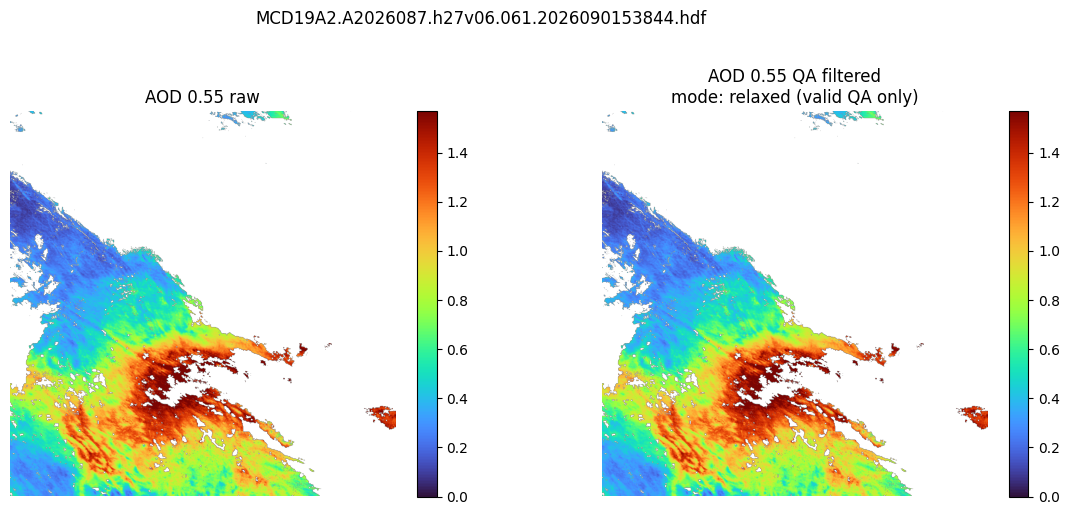

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path

# Su dung lai hdf_file/subdatasets neu da co; neu chua thi tu khoi tao
if "hdf_file" not in globals():
    hdf_dir = Path("./maiac_data")
    hdf_files = sorted(hdf_dir.glob("*.hdf"))
    if not hdf_files:
        raise FileNotFoundError("Khong tim thay file .hdf trong ./maiac_data")
    hdf_file = hdf_files[0]

if "subdatasets" not in globals() or not subdatasets:
    with rasterio.open(hdf_file) as src:
        subdatasets = list(src.subdatasets)

def _pick_subdataset(name_part: str):
    s = next((x for x in subdatasets if name_part in x), None)
    if s is None:
        raise RuntimeError(f"Khong tim thay subdataset: {name_part}")
    return s

aod_ds = _pick_subdataset("Optical_Depth_055")
qa_ds = _pick_subdataset("AOD_QA")

# 1) Doc Optical_Depth_055 + metadata scale/offset
with rasterio.open(aod_ds) as ds_aod:
    aod_raw = ds_aod.read(1).astype("float32")
    aod_nodata = ds_aod.nodata
    tags = ds_aod.tags()
    btags = ds_aod.tags(1)

    def _to_float(v, default):
        try:
            return float(v)
        except Exception:
            return default

    scale = _to_float(btags.get("scale_factor", tags.get("scale_factor", 0.001)), 0.001)
    offset = _to_float(btags.get("add_offset", tags.get("add_offset", 0.0)), 0.0)

    fill_candidates = [
        btags.get("_FillValue"),
        btags.get("fill_value"),
        tags.get("_FillValue"),
        tags.get("fill_value"),
        aod_nodata,
    ]
    aod_fill = next((float(v) for v in fill_candidates if v is not None), None)

# 2) Convert sang AOD that
if aod_fill is not None:
    aod_raw[aod_raw == aod_fill] = np.nan
aod = aod_raw * scale + offset

# Loai bo gia tri bat thuong de tranh plot bi vo nghia
aod[(aod < 0) | (aod > 5)] = np.nan

# 3) Loc theo AOD_QA
with rasterio.open(qa_ds) as ds_qa:
    qa = ds_qa.read(1).astype("int32")
    qa_nodata = ds_qa.nodata
    qtags = ds_qa.tags()
    qb = ds_qa.tags(1)
    qa_fill = qb.get("_FillValue", qtags.get("_FillValue", qa_nodata))
    if qa_fill is not None:
        qa_fill = int(float(qa_fill))

valid_aod = np.isfinite(aod)
if qa_fill is not None:
    valid_qa = qa != qa_fill
else:
    valid_qa = np.ones_like(qa, dtype=bool)

# Rule chat: 2 bit thap nhat == 0
strict_mask = valid_aod & valid_qa & ((qa & 0b11) == 0)

# Rule no rong: giu pixel hop le, bo dieu kien bitmask
relaxed_mask = valid_aod & valid_qa

strict_count = int(np.sum(strict_mask))
relaxed_count = int(np.sum(relaxed_mask))
total_count = int(aod.size)

if strict_count > max(1000, int(0.005 * total_count)):
    chosen_mask = strict_mask
    qa_mode = "strict (qa bits 0-1 == 0)"
else:
    chosen_mask = relaxed_mask
    qa_mode = "relaxed (valid QA only)"

aod_good = np.where(chosen_mask, aod, np.nan)

print(f"Scale={scale}, Offset={offset}")
print("Tong pixel:", total_count)
print("Valid AOD:", int(np.sum(valid_aod)))
print("QA strict count:", strict_count)
print("QA relaxed count:", relaxed_count)
print("Dang dung QA mode:", qa_mode)

# 4) Ve nhanh ban do AOD raw va AOD da loc
if np.all(~np.isfinite(aod_good)):
    raise RuntimeError("Tat ca pixel bi mask. Thu no rong dieu kien QA hoac doi file/ ngay khac.")

vmax_raw = np.nanpercentile(aod[valid_aod], 98) if np.any(valid_aod) else 1.5
vmax_good = np.nanpercentile(aod_good[np.isfinite(aod_good)], 98) if np.any(np.isfinite(aod_good)) else 1.5
vmax_raw = float(max(0.3, min(vmax_raw, 2.5)))
vmax_good = float(max(0.3, min(vmax_good, 2.5)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(aod, cmap="turbo", vmin=0, vmax=vmax_raw)
axes[0].set_title("AOD 0.55 raw")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(aod_good, cmap="turbo", vmin=0, vmax=vmax_good)
axes[1].set_title(f"AOD 0.55 QA filtered\nmode: {qa_mode}")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle(f"{Path(hdf_file).name}", y=1.02)
plt.tight_layout()
plt.show()

Ngay duoc chon: 2026089 - so file: 7
So tile hop le (AOD): 7
Scale=0.001, Offset=0.0, mode=raw-no-qa
So tile dung duoc: 7
Valid pixel: 1658949 / 12960000


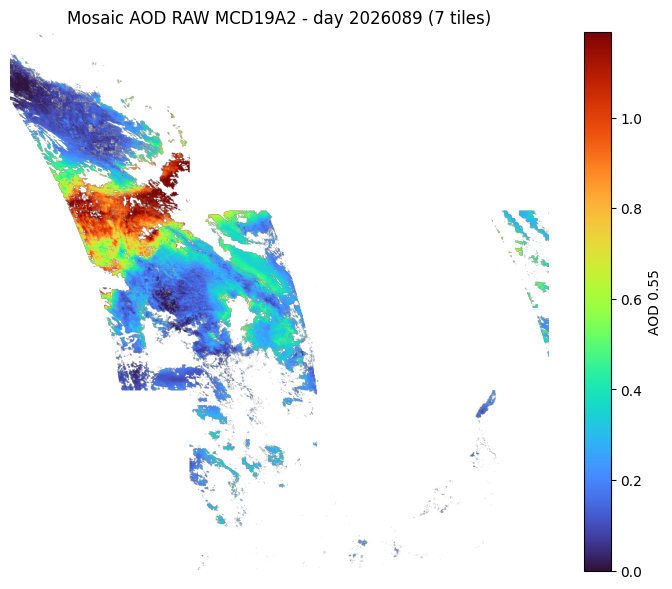

In [32]:
import re
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.merge import merge

hdf_dir = Path("./maiac_data")
hdf_files = sorted(hdf_dir.glob("*.hdf"))
if not hdf_files:
    raise FileNotFoundError("Khong tim thay file .hdf trong ./maiac_data")

# Gom file theo ngay AYYYYDDD trong ten file
files_by_day = defaultdict(list)
for f in hdf_files:
    m = re.search(r"\.A(\d{7})\.", f.name)
    if m:
        files_by_day[m.group(1)].append(f)

if not files_by_day:
    raise RuntimeError("Khong tach duoc ngay tu ten file HDF")

# Chon ngay moi nhat de mosaic
target_day = sorted(files_by_day.keys())[-1]
day_files = sorted(files_by_day[target_day])
print("Ngay duoc chon:", target_day, "- so file:", len(day_files))

aod_paths = []
for f in day_files:
    with rasterio.open(f) as src:
        subdatasets = list(src.subdatasets)
    aod_ds = next((s for s in subdatasets if "Optical_Depth_055" in s), None)
    if aod_ds:
        aod_paths.append(aod_ds)

if not aod_paths:
    raise RuntimeError("Khong tim thay Optical_Depth_055 trong cac tile cua ngay da chon")

print("So tile hop le (AOD):", len(aod_paths))

def _open_valid(paths, label):
    valid = []
    for p in paths:
        try:
            ds = rasterio.open(p)
            if ds.count < 1:
                ds.close()
                print(f"Bo qua {label} (khong co band): {p}")
                continue
            _ = ds.read(1, window=((0, 1), (0, 1)))
            valid.append(ds)
        except Exception as e:
            print(f"Bo qua {label} loi: {p}\n  -> {e}")
    return valid

aod_srcs = _open_valid(aod_paths, "AOD")
if not aod_srcs:
    raise RuntimeError("Khong con tile AOD hop le sau khi kiem tra du lieu")

# Merge theo band 1
aod_mosaic, out_transform = merge(aod_srcs, indexes=[1], method="first")

aod_meta = aod_srcs[0].meta.copy()
aod_tags = aod_srcs[0].tags()
aod_btags = aod_srcs[0].tags(1)
for ds in aod_srcs:
    ds.close()

aod_raw = aod_mosaic[0].astype("float32")

def _to_float(v, default):
    try:
        return float(v)
    except Exception:
        return default

scale = _to_float(aod_btags.get("scale_factor", aod_tags.get("scale_factor", 0.001)), 0.001)
offset = _to_float(aod_btags.get("add_offset", aod_tags.get("add_offset", 0.0)), 0.0)

fill_candidates = [
    aod_btags.get("_FillValue"),
    aod_btags.get("fill_value"),
    aod_tags.get("_FillValue"),
    aod_tags.get("fill_value"),
    aod_meta.get("nodata"),
]
aod_fill = next((float(v) for v in fill_candidates if v is not None), None)

if aod_fill is not None:
    aod_raw[aod_raw == aod_fill] = np.nan

# RAW: khong loc QA, chi scale + loc gia tri bat thuong
aod = aod_raw * scale + offset
aod[(aod < 0) | (aod > 5)] = np.nan
aod_good = aod  # giu ten bien de Cell 6 dung tiep

print(f"Scale={scale}, Offset={offset}, mode=raw-no-qa")
print("So tile dung duoc:", len(aod_srcs))
print("Valid pixel:", int(np.sum(np.isfinite(aod_good))), "/", aod_good.size)

vmax = np.nanpercentile(aod_good[np.isfinite(aod_good)], 98) if np.any(np.isfinite(aod_good)) else 1.5
vmax = float(max(0.3, min(vmax, 2.5)))

plt.figure(figsize=(9, 7))
im = plt.imshow(aod_good, cmap="turbo", vmin=0, vmax=vmax)
plt.colorbar(im, label="AOD 0.55")
plt.title(f"Mosaic AOD RAW MCD19A2 - day {target_day} ({len(aod_srcs)} tiles)")
plt.axis("off")
plt.show()

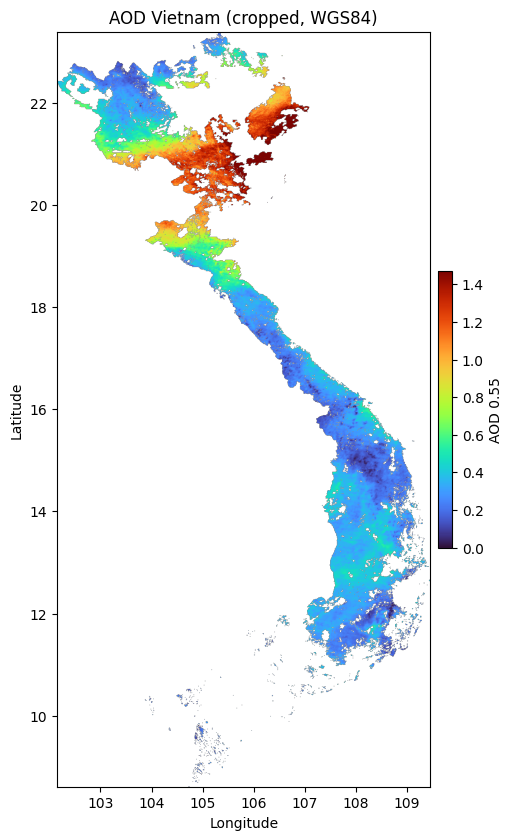

In [33]:
import json
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import geometry_mask
from rasterio.warp import transform_geom, calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds

if "aod_good" not in globals() or "out_transform" not in globals():
    raise RuntimeError("Hay chay Cell 5 truoc de tao aod_good va out_transform")

if "aod_paths" in globals() and len(aod_paths) > 0:
    with rasterio.open(aod_paths[0]) as ds0:
        mosaic_crs = ds0.crs
else:
    raise RuntimeError("Khong tim thay aod_paths, hay chay lai Cell 5")

with open("geoBoundaries-VNM-ADM1_simplified.geojson", "r", encoding="utf-8") as f:
    gj = json.load(f)

vn_geoms_wgs84 = [feat["geometry"] for feat in gj.get("features", []) if feat.get("geometry") is not None]
if not vn_geoms_wgs84:
    raise RuntimeError("Khong doc duoc geometry tu GeoJSON Viet Nam")

vn_geoms_mosaic = [
    transform_geom("EPSG:4326", mosaic_crs, g, precision=6)
    for g in vn_geoms_wgs84
]

inside_mask = geometry_mask(
    vn_geoms_mosaic,
    out_shape=aod_good.shape,
    transform=out_transform,
    invert=True,
    all_touched=False,
)
aod_vn = np.where(inside_mask, aod_good, np.nan)

if np.all(~np.isfinite(aod_vn)):
    raise RuntimeError("Sau khi clip khong con pixel hop le")

h, w = aod_vn.shape
left, bottom, right, top = array_bounds(h, w, out_transform)
dst_transform, dst_w, dst_h = calculate_default_transform(
    mosaic_crs, "EPSG:4326", w, h, left, bottom, right, top, resolution=0.01
)

aod_wgs84 = np.full((dst_h, dst_w), np.nan, dtype="float32")
reproject(
    source=aod_vn.astype("float32"),
    destination=aod_wgs84,
    src_transform=out_transform,
    src_crs=mosaic_crs,
    dst_transform=dst_transform,
    dst_crs="EPSG:4326",
    src_nodata=np.nan,
    dst_nodata=np.nan,
    resampling=Resampling.nearest,
)

x_min = dst_transform.c
x_max = dst_transform.c + dst_transform.a * dst_w
y_max = dst_transform.f
y_min = dst_transform.f + dst_transform.e * dst_h

# Crop vao phan co du lieu de ban do Viet Nam hien thi to hon
valid = np.isfinite(aod_wgs84)
if not np.any(valid):
    raise RuntimeError("Khong con pixel hop le sau reproject")

rows = np.where(valid.any(axis=1))[0]
cols = np.where(valid.any(axis=0))[0]
r0, r1 = rows[0], rows[-1]
c0, c1 = cols[0], cols[-1]

aod_crop = aod_wgs84[r0:r1 + 1, c0:c1 + 1]

x_left = x_min + c0 * dst_transform.a
x_right = x_min + (c1 + 1) * dst_transform.a
y_top = y_max + r0 * dst_transform.e
y_bottom = y_max + (r1 + 1) * dst_transform.e

vmax = np.nanpercentile(aod_crop[np.isfinite(aod_crop)], 98)
vmax = float(max(0.3, min(vmax, 2.5)))

fig, ax = plt.subplots(figsize=(5, 9))
im = ax.imshow(
    aod_crop,
    cmap="turbo",
    vmin=0,
    vmax=vmax,
    extent=[x_left, x_right, y_bottom, y_top],
    origin="upper",
)
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02, shrink=0.85)
cbar.set_label("AOD 0.55")

ax.set_title("AOD Vietnam (cropped, WGS84)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()